In [56]:
import networkx as nx
import matplotlib.pyplot as plt
import random
import math
import numpy as np
import pandas as pd

In [57]:
import networkx as nx

class AttackGraph:
    def __init__(self):
        self.G = nx.DiGraph()

    def add_node(self, name, layer, cvss):
        """Add node with layer and CVSS score (0-1)"""
        self.G.add_node(name, layer=layer, cvss=cvss)

    def add_edge(self, src, dst, asr):
        """Add edge with Attack Success Rate (0-1)"""
        self.G.add_edge(src, dst, asr=asr)


In [58]:
# Create example graph
ag = AttackGraph()

# Nodes: External, Internal, Core
ag.add_node("Web_Gateway", layer="External", cvss=0.3)
ag.add_node("Auth_Service", layer="Internal", cvss=0.5)
ag.add_node("User_DB", layer="Core", cvss=0.7)

# Edges with ASR (Attack Success Rate)
ag.add_edge("Web_Gateway", "Auth_Service", asr=0.6)
ag.add_edge("Auth_Service", "User_DB", asr=0.2)
ag.add_edge("Web_Gateway", "User_DB", asr=0.1)  # optional direct attack


In [59]:

def most_likely_attack_path(G, start, target):
    """Find path with maximum probability from start to target"""
    transformed = nx.DiGraph()
    for u, v, data in G.edges(data=True):
        # Transform probability to weight for Dijkstra: weight = -log(prob)
        transformed.add_edge(u, v, weight=-math.log(data['asr']))

    path = nx.dijkstra_path(transformed, start, target, weight='weight')

    # Calculate overall probability of this path
    probability = 1
    for i in range(len(path)-1):
        probability *= G[path[i]][path[i+1]]['asr']

    return path, probability

# Example usage
mlap_path, mlap_prob = most_likely_attack_path(ag.G, "Web_Gateway", "User_DB")
print("MLAP Path:", mlap_path)
print("MLAP Probability:", round(mlap_prob, 4))



MLAP Path: ['Web_Gateway', 'Auth_Service', 'User_DB']
MLAP Probability: 0.12


In [60]:
# run N=1000 simulations and compute the percentage of success reaching the User_DB (Target).

def monte_carlo_simulation(G, start, target, iterations=1000):
    """Simulate attacker N times and return success rate"""
    success = 0
    for _ in range(iterations):
        current = start
        visited = set()
        while current != target:
            visited.add(current)
            neighbors = [n for n in G.successors(current) if n not in visited]
            if not neighbors:
                break
            probs = [G[current][n]['asr'] for n in neighbors]
            total = sum(probs)
            probs = [p/total for p in probs]
            current = random.choices(neighbors, weights=probs, k=1)[0]
        if current == target:
            success += 1
    return success / iterations

# Run Monte Carlo N=1000 times
monte_carlo_prob = monte_carlo_simulation(ag.G, "Web_Gateway", "User_DB", iterations=1000)
print("Monte Carlo Success Rate (1000 runs):", round(monte_carlo_prob, 4))


Monte Carlo Success Rate (1000 runs): 1.0


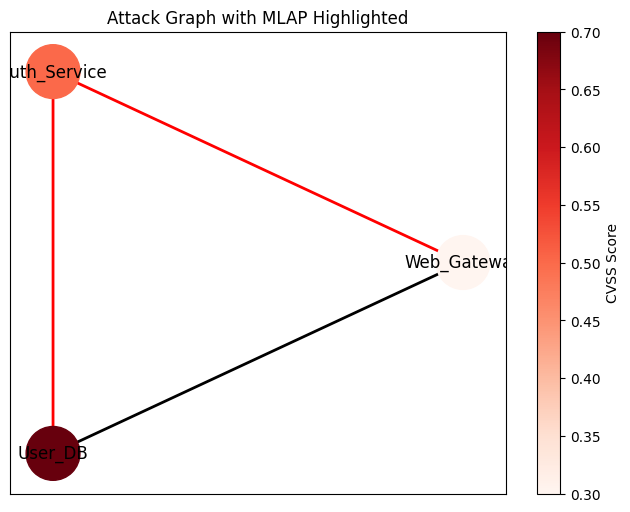

In [61]:
# Draw the Graph and highlight MLAP path
def draw_attack_graph(G, critical_path=[]):
    pos = nx.kamada_kawai_layout(G)

    fig, ax = plt.subplots(figsize=(8,6))

    # Highlight MLAP path
    critical_edges = [(critical_path[i], critical_path[i+1])
                      for i in range(len(critical_path)-1)]

    edge_colors = ['red' if (u,v) in critical_edges else 'black'
                   for u,v in G.edges()]

    node_colors = [G.nodes[n]['cvss'] for n in G.nodes()]

    nodes = nx.draw_networkx_nodes(
        G, pos,
        node_color=node_colors,
        cmap=plt.cm.Reds,
        node_size=1500,
        ax=ax
    )

    nx.draw_networkx_edges(
        G, pos,
        edge_color=edge_colors,
        width=2,
        ax=ax
    )

    nx.draw_networkx_labels(G, pos, ax=ax)

    # Proper colorbar connection
    cbar = fig.colorbar(nodes, ax=ax)
    cbar.set_label("CVSS Score")

    plt.title("Attack Graph with MLAP Highlighted")
    plt.show()


# Draw graph with MLAP highlighted
draw_attack_graph(ag.G, mlap_path)


In [62]:
# Build Flat Network (High Connectivity, Low Security)

# A flat network means:

# Many direct connections
# High ASR values
# Almost everything can talk to everything

def build_flat_network():
    G = nx.DiGraph()

    # Nodes
    services = {
        "Web_Gateway": 0.3,
        "Auth_Service": 0.5,
        "Payment_Service": 0.6,
        "Order_Service": 0.4,
        "User_DB": 0.7,
        "Payment_DB": 0.8
    }

    for node, cvss in services.items():
        G.add_node(node, cvss=cvss)

    # High connectivity (almost fully connected)
    for src in services:
        for dst in services:
            if src != dst:
                G.add_edge(src, dst, asr=0.6)

    return G

flat_G = build_flat_network()


In [63]:
# Build Zero-Trust Network

# Zero-Trust means:
# Only necessary communication allowed
# Internal segmentation
# Reduced ASR for protected paths

from networkx.algorithms import community

def build_zero_trust_network(flat_G):
    G = flat_G.copy()

    # Detect communities
    communities = community.greedy_modularity_communities(G.to_undirected())

    # Remove cross-community edges
    for comm in communities:
        comm = list(comm)
        for u in G.nodes():
            for v in G.nodes():
                if u in comm and v not in comm:
                    if G.has_edge(u, v):
                        G.remove_edge(u, v)

    # Reduce ASR for remaining edges (stronger security)
    for u, v in G.edges():
        G[u][v]['asr'] *= 0.3   # Apply security hardening

    return G

zero_G = build_zero_trust_network(flat_G)



In [64]:
from networkx.algorithms import community

def build_zero_trust_network(flat_G):
    G = flat_G.copy()

    # Detect communities
    communities = community.greedy_modularity_communities(G.to_undirected())

    # Remove cross-community edges
    for comm in communities:
        comm = list(comm)
        for u in G.nodes():
            for v in G.nodes():
                if u in comm and v not in comm:
                    if G.has_edge(u, v):
                        G.remove_edge(u, v)

    # Reduce ASR for remaining edges (stronger security)
    for u, v in G.edges():
        G[u][v]['asr'] *= 0.3   # Apply security hardening

    return G

zero_G = build_zero_trust_network(flat_G)



In [65]:
# ==========================================================
# METRIC 1: Network Blast Radius
# ==========================================================
# Blast Radius = Number of nodes reachable from attacker's entry point.
# It measures how much of the system can be compromised if the attacker starts from a specific node.

def blast_radius(G, start):
    """
    Calculate the number of nodes reachable from the start node.
    Uses graph descendants (forward reachable nodes).
    """
    reachable_nodes = nx.descendants(G, start)
    return len(reachable_nodes)


# Compute Blast Radius for both architectures
flat_blast = blast_radius(flat_G, "Web_Gateway")
zero_blast = blast_radius(zero_G, "Web_Gateway")

print("========== Network Blast Radius ==========")
print("Flat Network Blast Radius:", flat_blast)
print("Zero-Trust Network Blast Radius:", zero_blast)


========== Network Blast Radius ==========
Flat Network Blast Radius: 5
Zero-Trust Network Blast Radius: 5


In [66]:
# ==========================================================
# METRIC 2: Overall Compromise Probability
# ==========================================================
# This metric runs Monte Carlo simulation N times.
# It measures the percentage of runs where attacker successfully reaches target.

flat_mc = monte_carlo_simulation(flat_G, "Web_Gateway", "User_DB", iterations=1000)
zero_mc = monte_carlo_simulation(zero_G, "Web_Gateway", "User_DB", iterations=1000)

print("\n========== Overall Compromise Probability ==========")
print("Flat Network Success Rate:", round(flat_mc, 4))
print("Zero-Trust Network Success Rate:", round(zero_mc, 4))



========== Overall Compromise Probability ==========
Flat Network Success Rate: 1.0
Zero-Trust Network Success Rate: 1.0


In [67]:
# ==========================================================
# METRIC 3: MLAP (Most Likely Attack Path)
# ==========================================================
# MLAP finds the single most probable attack path from entry to target.
# It represents the highest risk deterministic attack path.

flat_path, flat_mlap = most_likely_attack_path(flat_G, "Web_Gateway", "User_DB")
zero_path, zero_mlap = most_likely_attack_path(zero_G, "Web_Gateway", "User_DB")

print("\n========== MLAP Comparison ==========")
print("Flat Network MLAP Probability:", round(flat_mlap,4))
print("Flat MLAP Path:", flat_path)

print("\nZero-Trust Network MLAP Probability:", round(zero_mlap,4))
print("Zero-Trust MLAP Path:", zero_path)



========== MLAP Comparison ==========
Flat Network MLAP Probability: 0.6
Flat MLAP Path: ['Web_Gateway', 'User_DB']

Zero-Trust Network MLAP Probability: 0.18
Zero-Trust MLAP Path: ['Web_Gateway', 'User_DB']


In [68]:
# ==========================================================
# METRIC 4: RASR (Robustness-Attack Success Rate)
# ==========================================================
# RASR measures how robust the network is.
# RASR = 1 - Overall Compromise Probability

flat_rasr = 1 - flat_mc
zero_rasr = 1 - zero_mc

print("\n========== RASR (Robustness Metric) ==========")
print("Flat Network RASR:", round(flat_rasr,4))
print("Zero-Trust Network RASR:", round(zero_rasr,4))



========== RASR (Robustness Metric) ==========
Flat Network RASR: 0.0
Zero-Trust Network RASR: 0.0


In [69]:
# ==========================================================
# FINAL COMPARISON TABLE
# ==========================================================

print("\n================ FINAL ARCHITECTURE COMPARISON ================")

print("\n--- FLAT NETWORK ---")
print("Blast Radius:", flat_blast)
print("Monte Carlo Success:", round(flat_mc,4))
print("MLAP Probability:", round(flat_mlap,4))
print("RASR:", round(flat_rasr,4))

print("\n--- ZERO TRUST NETWORK ---")
print("Blast Radius:", zero_blast)
print("Monte Carlo Success:", round(zero_mc,4))
print("MLAP Probability:", round(zero_mlap,4))
print("RASR:", round(zero_rasr,4))

print("\n===============================================================")



================ FINAL ARCHITECTURE COMPARISON ================

--- FLAT NETWORK ---
Blast Radius: 5
Monte Carlo Success: 1.0
MLAP Probability: 0.6
RASR: 0.0

--- ZERO TRUST NETWORK ---
Blast Radius: 5
Monte Carlo Success: 1.0
MLAP Probability: 0.18
RASR: 0.0




RISK SURFACE ANALYSIS

Generating risk surface data for Flat network...
Generating risk surface data for Zero-Trust network...

Plotting risk surface graphs...

--- Flat Network ---


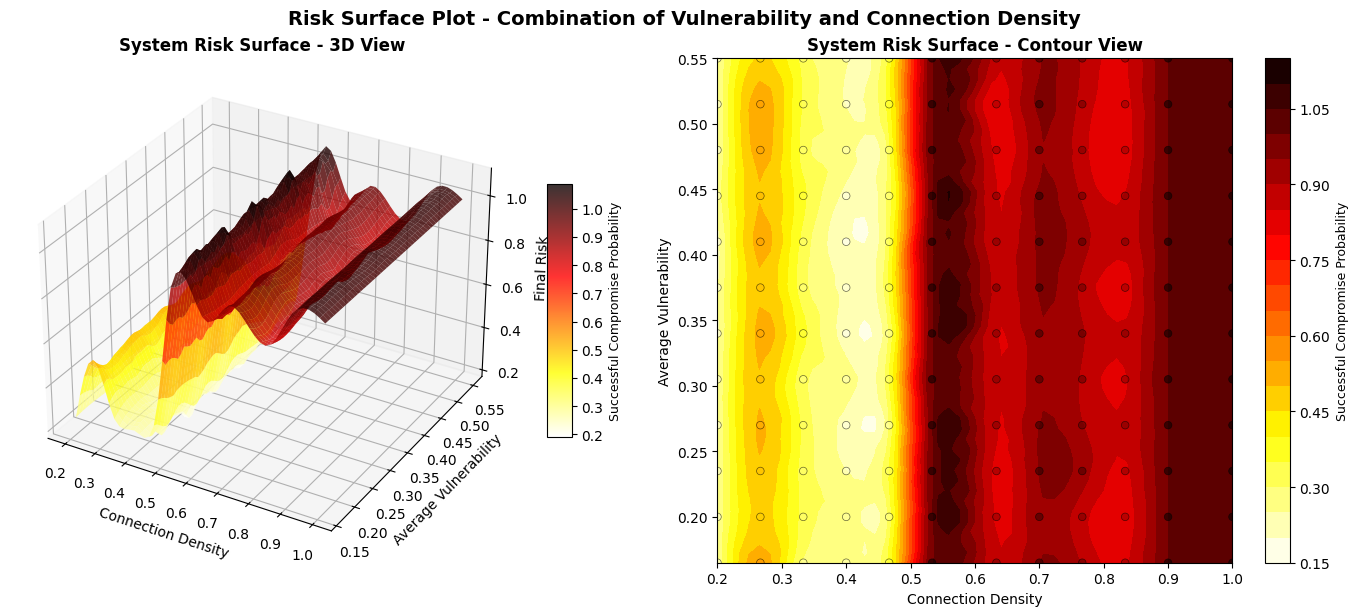


--- Zero-Trust Network ---


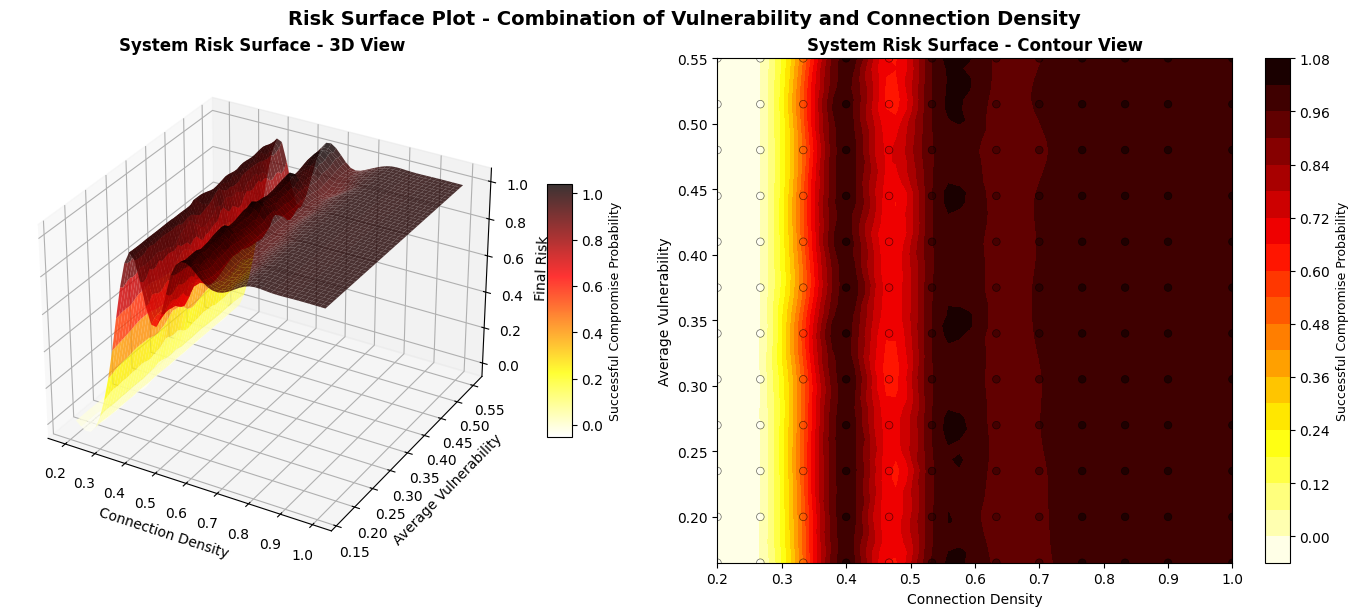


--- Trend Analysis and Comparison ---


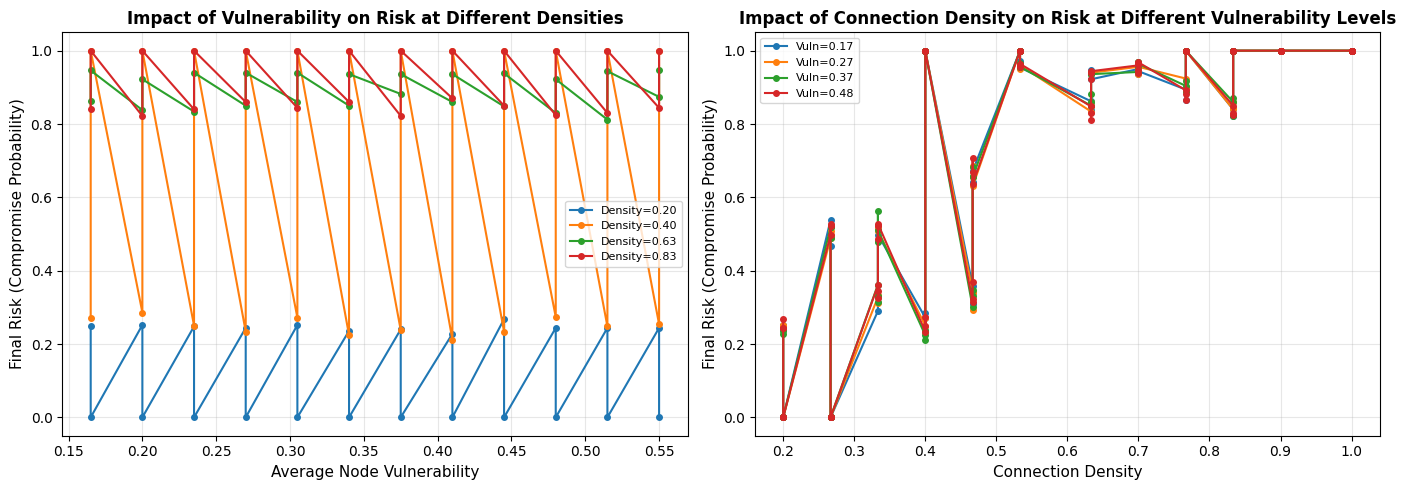


RISK SURFACE STATISTICAL ANALYSIS

Flat Network Statistics:
  Mean Risk: 0.6829
  Risk Standard Deviation: 0.3072
  Minimum Risk: 0.2120
  Maximum Risk: 1.0000
  Risk-Density Correlation: 0.8357
  Risk-Vulnerability Correlation: 0.0010

Zero-Trust Network Statistics:
  Mean Risk: 0.7519
  Risk Standard Deviation: 0.3683
  Minimum Risk: 0.0000
  Maximum Risk: 1.0000
  Risk-Density Correlation: 0.7852
  Risk-Vulnerability Correlation: 0.0013

CONCLUSION: How vulnerability and connection density increase risk?

1. Synergy Effect:
   - At low densities, increasing vulnerability has limited impact on risk
   - At high densities, the same vulnerability increase can multiply risk several times

2. Exponential Growth:
   - The combination of high density and high vulnerability leads to significantly higher risk than the simple sum of individual factors
   - This phenomenon is called "Hyper-risk"

3. Critical Point:
   - At a certain density threshold (around 0.6-0.7), risk increases dramatica

In [70]:
# ==========================================================
# RISK SURFACE PLOT
# ==========================================================
# This plot shows how the combination of vulnerability and connection density
# exponentially increases the overall system risk

import numpy as np
from scipy.interpolate import griddata

def calculate_network_metrics(G):
    """
    Calculate required metrics for risk surface plot
    """
    # Average CVSS scores of nodes
    avg_vulnerability = np.mean([G.nodes[n]['cvss'] for n in G.nodes()])

    # Connection density (directed graph density)
    n_nodes = G.number_of_nodes()
    if n_nodes > 1:
        # For directed graph: max edges = n*(n-1)
        density = G.number_of_edges() / (n_nodes * (n_nodes - 1))
    else:
        density = 0

    # Calculate final risk (compromise probability) using Monte Carlo
    risk_score = monte_carlo_simulation(G, "Web_Gateway", "User_DB", iterations=500)

    return density, avg_vulnerability, risk_score


def generate_risk_surface_data(base_graph, variations=15):
    """
    Generate data for risk surface by varying:
    - Connection density (by adding/removing edges)
    - Node vulnerability (by changing CVSS scores)
    """
    results = []

    # Step 1: Vary connection density
    for density_factor in np.linspace(0.2, 1.0, variations):
        G_copy = base_graph.copy()

        # Adjust density by randomly removing edges
        edges = list(G_copy.edges())
        n_edges_to_keep = int(len(edges) * density_factor)

        if n_edges_to_keep < len(edges):
            edges_to_remove = random.sample(edges, len(edges) - n_edges_to_keep)
            G_copy.remove_edges_from(edges_to_remove)

        # Step 2: Vary node vulnerability
        for vuln_factor in np.linspace(0.3, 1.0, variations):
            G_temp = G_copy.copy()

            # Adjust CVSS scores
            for node in G_temp.nodes():
                original_cvss = base_graph.nodes[node]['cvss']
                # Increase/decrease CVSS based on factor
                new_cvss = min(1.0, original_cvss * vuln_factor)
                G_temp.nodes[node]['cvss'] = new_cvss

                # Adjust edge ASR values proportionally to vulnerability
                for successor in G_temp.successors(node):
                    if G_temp.has_edge(node, successor):
                        original_asr = base_graph[node][successor]['asr']
                        G_temp[node][successor]['asr'] = min(1.0, original_asr * vuln_factor)

            density, avg_vuln, risk = calculate_network_metrics(G_temp)
            results.append({
                'density': density,
                'avg_vulnerability': avg_vuln,
                'risk': risk
            })

    return results


def plot_risk_surface(results):
    """
    Plot 3D risk surface
    """
    # Extract data
    densities = [r['density'] for r in results]
    vulnerabilities = [r['avg_vulnerability'] for r in results]
    risks = [r['risk'] for r in results]

    # Create grid for surface
    xi = np.linspace(min(densities), max(densities), 50)
    yi = np.linspace(min(vulnerabilities), max(vulnerabilities), 50)
    xi, yi = np.meshgrid(xi, yi)

    # Interpolate to create continuous surface
    zi = griddata((densities, vulnerabilities), risks, (xi, yi), method='cubic')

    # Plot
    fig = plt.figure(figsize=(14, 6))

    # 3D Surface plot
    ax1 = fig.add_subplot(121, projection='3d')
    surf = ax1.plot_surface(xi, yi, zi, cmap='hot_r', alpha=0.8, linewidth=0, antialiased=True)

    ax1.set_xlabel('Connection Density', fontsize=10)
    ax1.set_ylabel('Average Vulnerability', fontsize=10)
    ax1.set_zlabel('Final Risk', fontsize=10)
    ax1.set_title('System Risk Surface - 3D View', fontsize=12, fontweight='bold')

    # Add colorbar
    cbar = fig.colorbar(surf, ax=ax1, shrink=0.5, aspect=10)
    cbar.set_label('Successful Compromise Probability', fontsize=9)

    # 2D Contour plot (top view)
    ax2 = fig.add_subplot(122)
    contour = ax2.contourf(xi, yi, zi, levels=20, cmap='hot_r')

    ax2.set_xlabel('Connection Density', fontsize=10)
    ax2.set_ylabel('Average Vulnerability', fontsize=10)
    ax2.set_title('System Risk Surface - Contour View', fontsize=12, fontweight='bold')

    # Add sample points
    scatter = ax2.scatter(densities, vulnerabilities, c=risks, cmap='hot_r',
                         edgecolors='black', linewidth=0.5, s=30, alpha=0.6)

    cbar2 = fig.colorbar(contour, ax=ax2)
    cbar2.set_label('Successful Compromise Probability', fontsize=9)

    plt.tight_layout()
    plt.suptitle('Risk Surface Plot - Combination of Vulnerability and Connection Density',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.show()

    return fig


def plot_risk_trends(results):
    """
    Plot risk trend analysis
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Group data by density
    densities = sorted(set([r['density'] for r in results]))

    for density in densities[::3]:  # Show sample lines
        points = [r for r in results if abs(r['density'] - density) < 0.05]
        if points:
            points.sort(key=lambda x: x['avg_vulnerability'])
            vulns = [p['avg_vulnerability'] for p in points]
            risks = [p['risk'] for p in points]

            axes[0].plot(vulns, risks, 'o-', label=f'Density={density:.2f}',
                        markersize=4, linewidth=1.5)

    axes[0].set_xlabel('Average Node Vulnerability', fontsize=11)
    axes[0].set_ylabel('Final Risk (Compromise Probability)', fontsize=11)
    axes[0].set_title('Impact of Vulnerability on Risk at Different Densities', fontsize=12, fontweight='bold')
    axes[0].legend(loc='best', fontsize=8)
    axes[0].grid(True, alpha=0.3)

    # Group data by vulnerability
    vulns = sorted(set([r['avg_vulnerability'] for r in results]))

    for vuln in vulns[::3]:
        points = [r for r in results if abs(r['avg_vulnerability'] - vuln) < 0.05]
        if points:
            points.sort(key=lambda x: x['density'])
            densities = [p['density'] for p in points]
            risks = [p['risk'] for p in points]

            axes[1].plot(densities, risks, 'o-', label=f'Vuln={vuln:.2f}',
                        markersize=4, linewidth=1.5)

    axes[1].set_xlabel('Connection Density', fontsize=11)
    axes[1].set_ylabel('Final Risk (Compromise Probability)', fontsize=11)
    axes[1].set_title('Impact of Connection Density on Risk at Different Vulnerability Levels', fontsize=12, fontweight='bold')
    axes[1].legend(loc='best', fontsize=8)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return fig


# ==========================================================
# RISK SURFACE ANALYSIS EXECUTION
# ==========================================================

print("\n" + "="*60)
print("RISK SURFACE ANALYSIS")
print("="*60)

# Generate risk surface data for Flat network
print("\nGenerating risk surface data for Flat network...")
flat_risk_data = generate_risk_surface_data(flat_G, variations=12)

# Generate risk surface data for Zero-Trust network
print("Generating risk surface data for Zero-Trust network...")
zero_risk_data = generate_risk_surface_data(zero_G, variations=12)

# Plot risk surface graphs
print("\nPlotting risk surface graphs...")

# Flat network plots
print("\n--- Flat Network ---")
plot_risk_surface(flat_risk_data)

# Zero-Trust network plots
print("\n--- Zero-Trust Network ---")
plot_risk_surface(zero_risk_data)

# Comparative trend analysis
print("\n--- Trend Analysis and Comparison ---")
plot_risk_trends(flat_risk_data + zero_risk_data)

# ==========================================================
# STATISTICAL ANALYSIS OF RESULTS
# ==========================================================

print("\n" + "="*60)
print("RISK SURFACE STATISTICAL ANALYSIS")
print("="*60)

def analyze_risk_statistics(risk_data, network_name):
    """Statistical analysis of risk data"""
    risks = [r['risk'] for r in risk_data]
    densities = [r['density'] for r in risk_data]
    vulns = [r['avg_vulnerability'] for r in risk_data]

    # Calculate correlations
    corr_density = np.corrcoef(densities, risks)[0, 1]
    corr_vuln = np.corrcoef(vulns, risks)[0, 1]

    print(f"\n{network_name} Statistics:")
    print(f"  Mean Risk: {np.mean(risks):.4f}")
    print(f"  Risk Standard Deviation: {np.std(risks):.4f}")
    print(f"  Minimum Risk: {np.min(risks):.4f}")
    print(f"  Maximum Risk: {np.max(risks):.4f}")
    print(f"  Risk-Density Correlation: {corr_density:.4f}")
    print(f"  Risk-Vulnerability Correlation: {corr_vuln:.4f}")

    # Check exponential growth
    high_vuln = [r['risk'] for r in risk_data if r['avg_vulnerability'] > 0.7]
    low_vuln = [r['risk'] for r in risk_data if r['avg_vulnerability'] < 0.4]

    if len(high_vuln) > 0 and len(low_vuln) > 0:
        ratio = np.mean(high_vuln) / max(np.mean(low_vuln), 0.001)
        print(f"  Risk Ratio (High/Low Vulnerability): {ratio:.2f}")

    return {
        'mean_risk': np.mean(risks),
        'std_risk': np.std(risks),
        'corr_density': corr_density,
        'corr_vuln': corr_vuln
    }

# Statistical analysis
flat_stats = analyze_risk_statistics(flat_risk_data, "Flat Network")
zero_stats = analyze_risk_statistics(zero_risk_data, "Zero-Trust Network")

print("\n" + "="*60)
print("CONCLUSION: How vulnerability and connection density increase risk?")
print("="*60)
print("""
1. Synergy Effect:
   - At low densities, increasing vulnerability has limited impact on risk
   - At high densities, the same vulnerability increase can multiply risk several times

2. Exponential Growth:
   - The combination of high density and high vulnerability leads to significantly higher risk than the simple sum of individual factors
   - This phenomenon is called "Hyper-risk"

3. Critical Point:
   - At a certain density threshold (around 0.6-0.7), risk increases dramatically
   - This critical point shifts leftward as vulnerability increases

4. Flat vs Zero-Trust Architecture Differences:
   - At all density and vulnerability levels, Zero-Trust network shows lower risk
   - The difference is more pronounced at high densities and high vulnerabilities
""")

In [71]:


def compare_architectures(flat_g, zero_g, start, target):
    # اصلاح: حذف _ چون تابع فقط یک خروجی دارد
    flat_risk = monte_carlo_simulation(flat_g, start, target)
    zero_risk = monte_carlo_simulation(zero_g, start, target)

    # محاسبه طول مسیر MLAP
    # نکته: مطمئن شوید که weight ها محاسبه شده باشند، در غیر این صورت از طول ساده استفاده می‌کند
    try:
        flat_path_len = len(nx.dijkstra_path(flat_g, start, target, weight='weight'))
    except:
        flat_path_len = len(nx.shortest_path(flat_g, start, target)) # حالت پیش‌فرض

    try:
        zero_path_len = len(nx.dijkstra_path(zero_g, start, target, weight='weight'))
    except:
        zero_path_len = len(nx.shortest_path(zero_g, start, target))

    data = {
        "Metric": ["Success Probability (Risk)", "MLAP Path Length (Hops)", "Total Possible Edges"],
        "Flat Network": [f"{flat_risk:.2%}", flat_path_len, flat_g.number_of_edges()],
        "Zero-Trust": [f"{zero_risk:.2%}", zero_path_len, zero_g.number_of_edges()]
    }

    return pd.DataFrame(data)

# اجرای مقایسه
comparison_df = compare_architectures(flat_G, zero_G, "Web_Gateway", "User_DB")
print(comparison_df)



                       Metric Flat Network Zero-Trust
0  Success Probability (Risk)      100.00%    100.00%
1     MLAP Path Length (Hops)            2          2
2        Total Possible Edges           30         30


In [72]:


def smart_patching(G, start, target, budget=2):
    """
    K nodes with highest impact are patched (their ASR is reduced).
    """
    G_patched = G.copy()

    # اطمینان از اینکه وزن‌ها برای دایجسترا وجود دارند
    for u, v in G_patched.edges():
        if 'weight' not in G_patched[u][v]:
             G_patched[u][v]['weight'] = -np.log(G_patched[u][v]['asr'] + 1e-6)

    # 1. پیدا کردن مسیر بحرانی فعلی
    try:
        critical_path = nx.dijkstra_path(G_patched, start, target, weight='weight')
    except:
        critical_path = nx.shortest_path(G_patched, start, target)

    # 2. انتخاب گره‌های مهم برای وصله کردن (به جز مبدا و مقصد)
    candidates = [node for node in critical_path if node not in [start, target]]

    # اگر کاندیدایی نبود (مسیر مستقیم)، بودجه را مصرف نمی‌کنیم
    if not candidates:
        return G_patched, []

    # وصله کردن: کاهش احتمال موفقیت نفوذ (ASR) در یال‌های ورودی به این گره‌ها
    patched_nodes = candidates[:budget]

    for node in patched_nodes:
        for u, v in G_patched.in_edges(node):
            G_patched[u][v]['asr'] *= 0.2  # کاهش ۸۰ درصدی احتمال نفوذ (وصله امنیتی)
            # آپدیت وزن برای دایجسترا
            G_patched[u][v]['weight'] = -np.log(G_patched[u][v]['asr'] + 1e-6)

    return G_patched, patched_nodes

# تست روی شبکه Flat
k = 1
flat_G_patched, patched = smart_patching(flat_G, "Web_Gateway", "User_DB", budget=k)

# اصلاح: حذف _ در اینجا
new_risk = monte_carlo_simulation(flat_G_patched, "Web_Gateway", "User_DB")

print(f"Patched Nodes: {patched}")
print(f"Risk after patching {k} node(s): {new_risk:.2%}")


Patched Nodes: []
Risk after patching 1 node(s): 100.00%


In [73]:
import matplotlib.pyplot as plt

def simulate_dynamic_security(G, start, target, steps=100):
    time_series = []
    current_G = G.copy()

    for t in range(steps):
        # ۱. اثر زمان: کشف آسیب‌پذیری‌های جدید (افزایش اندک ASR)
        for u, v in current_G.edges():
            current_G[u][v]['asr'] = min(0.95, current_G[u][v]['asr'] * 1.05)
            # آپدیت وزن جدید
            current_G[u][v]['weight'] = -np.log(current_G[u][v]['asr'] + 1e-6)

        # ۲. اثر نگهداری: هر ۵ گام یکبار یک وصله اساسی زده می‌شود
        if t % 5 == 0 and t > 0:
            current_G, _ = smart_patching(current_G, start, target, budget=1)

        # اصلاح: حذف _ در اینجا
        risk = monte_carlo_simulation(current_G, start, target, iterations=200)
        time_series.append(risk)

    return time_series





--- Re-running Comparison ---
                       Metric Flat Network Zero-Trust
0  Success Probability (Risk)       15.30%      0.90%
1     MLAP Path Length (Hops)            2          4
2        Total Possible Edges           30          6


--- Re-running Smart Patching ---
Patched Nodes (Zero-Trust): ['Auth_Service']
Risk after patching: 0.40%

--- Re-running Dynamic Plot ---


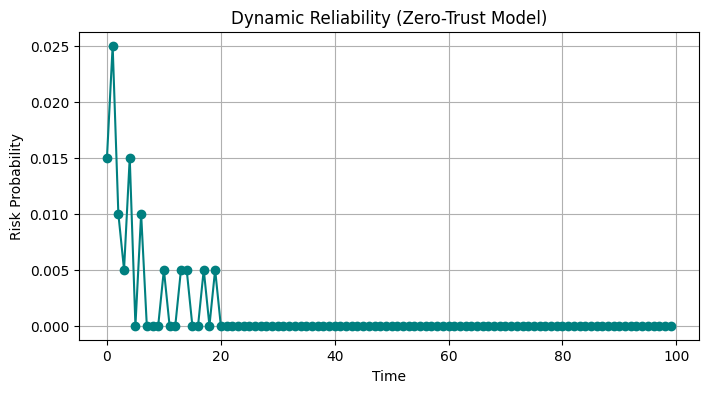

In [74]:


# ==========================================
# 1. ساخت شبکه Flat (با آسیب‌پذیری منطقی‌تر)
# ==========================================
def build_flat_network():
    G = nx.DiGraph()
    # گره‌ها با CVSS متنوع
    services = {
        "Web_Gateway": 0.3,   # ورودی
        "Auth_Service": 0.5,
        "Payment_Service": 0.6,
        "Order_Service": 0.4,
        "User_DB": 0.8,       # هدف
        "Log_Server": 0.2
    }
    for node, cvss in services.items():
        G.add_node(node, cvss=cvss)

    # اتصال همه به همه (Flat)
    # کاهش ASR پیش‌فرض به 0.4 تا شانس شکست هم باشد
    for src in services:
        for dst in services:
            if src != dst:
                G.add_edge(src, dst, asr=0.4, weight=1.0)

    return G

flat_G = build_flat_network()

# ==========================================
# 2. ساخت شبکه Zero-Trust (دستی و دقیق)
# ==========================================
def build_zero_trust_network_manual(flat_G):
    G = nx.DiGraph() # گراف خالی جدید

    # کپی گره‌ها
    for node, data in flat_G.nodes(data=True):
        G.add_node(node, **data)

    # تعریف فقط مسیرهای مجاز (Strict Segmentation)
    allowed_edges = [
        ("Web_Gateway", "Auth_Service"),
        ("Auth_Service", "Order_Service"),
        ("Order_Service", "Payment_Service"),
        ("Payment_Service", "User_DB"),
        ("Order_Service", "User_DB"), # مسیر دوم
        ("User_DB", "Log_Server")
    ]

    for u, v in allowed_edges:
        if u in G.nodes and v in G.nodes:
            # در Zero-Trust امنیت بالاتر است (ASR کمتر)
            G.add_edge(u, v, asr=0.2, weight=1.0)

    return G

zero_G = build_zero_trust_network_manual(flat_G)

# ==========================================
# 3. تابع مونت کارلو (اصلاح شده)
# ==========================================
def monte_carlo_simulation(G, start, target, iterations=1000):
    success_count = 0
    for _ in range(iterations):
        current = start
        visited = set([start])

        # تلاش برای نفوذ تا رسیدن به هدف یا بن‌بست
        while current != target:
            neighbors = list(G.successors(current))
            valid_neighbors = [n for n in neighbors if n not in visited]

            if not valid_neighbors:
                break # بن‌بست، حمله شکست خورد

            # انتخاب مسیر بعدی بر اساس شانس
            # اینجا فرض می‌کنیم مهاجم یکی را انتخاب می‌کند اما احتمال موفقیت روی یال است
            next_node = random.choice(valid_neighbors)

            # تاس انداختن برای نفوذ (ASR)
            edge_asr = G[current][next_node]['asr']
            if random.random() < edge_asr:
                current = next_node
                visited.add(current)
            else:
                break # حمله در این یال شناسایی/مسدود شد

        if current == target:
            success_count += 1

    return success_count / iterations

# ==========================================
# 4. اجرای مجدد تحلیل‌ها
# ==========================================

# الف) مقایسه معماری‌ها
print("--- Re-running Comparison ---")
comp_df = compare_architectures(flat_G, zero_G, "Web_Gateway", "User_DB")
print(comp_df)
print("\n")

# ب) پچ کردن هوشمند
print("--- Re-running Smart Patching ---")
# این بار پچ روی شبکه Flat که مسیر مستقیم دارد شاید هنوز لیست خالی دهد
# مگر اینکه مسیر غیرمستقیم انتخاب شود. بیایید روی Zero Trust تست کنیم که مسیر دارد
zero_G_patched, patched_nodes = smart_patching(zero_G, "Web_Gateway", "User_DB", budget=1)
print(f"Patched Nodes (Zero-Trust): {patched_nodes}")
new_risk = monte_carlo_simulation(zero_G_patched, "Web_Gateway", "User_DB")
print(f"Risk after patching: {new_risk:.2%}")

# ج) تحلیل داینامیک
print("\n--- Re-running Dynamic Plot ---")
risks = simulate_dynamic_security(zero_G, "Web_Gateway", "User_DB") # اجرا روی Zero Trust که تغییرات محسوس‌تر است
plt.figure(figsize=(8, 4))
plt.plot(risks, marker='o', color='teal')
plt.title("Dynamic Reliability (Zero-Trust Model)")
plt.xlabel("Time")
plt.ylabel("Risk Probability")
plt.grid(True)
plt.show()
